In [1]:
import torch
import sigpde.torch as pde
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
class NonLinearSDE():
    def __init__(self):
        return
    
    @staticmethod
    def sample(n, theta=0, dt=0.005, start=0, stop=1, thin=0, device=torch.device('cuda:0'), dtype=torch.float64):
        # Initialize tensors for the results
        num_steps = math.ceil((stop - start) / dt)
        X = torch.zeros(n, num_steps + 1, device=device, dtype=dtype)
        Y = torch.zeros(n, num_steps + 1, device=device, dtype=dtype)
        X[0], Y[0] = 0, 0

        # Wiener processes for the batch
        W1 = math.sqrt(dt) * torch.randn(n, num_steps, device=device, dtype=dtype)
        W2 = math.sqrt(dt) * torch.randn(n, num_steps, device=device, dtype=dtype)

        for t in range(1, num_steps + 1):
            drift_X = -X[:,t - 1]**3
            diffusion_X = torch.sqrt(1 + X[:,t - 1] ** 2)

            drift_Y = theta * torch.sin(X[:,t - 1]) - Y[:,t - 1]
            diffusion_Y = math.sqrt(theta) * torch.exp(-X[:,t - 1] ** 2) + 0.5

            X[:,t] = X[:,t - 1] + drift_X * dt + diffusion_X * W1[:,t - 1]
            Y[:,t] = Y[:,t - 1] + drift_Y * dt + diffusion_Y * W2[:,t - 1]

        return X.view(n, num_steps + 1, 1)[:,range(0, num_steps + 1, 2**thin),:], Y.view(n, num_steps + 1, -1)[:,range(0, num_steps + 1, 2**thin),:]
    
    @staticmethod
    def thin(x, short_min=0.5, short_max=1):
        x = x.clone()
        l = x.shape[1]
        n = x.shape[0]
        device = x.device
        short_min = math.ceil(l * short_min)
        short_max = math.ceil((l - 1) * short_max)
        thin_int = torch.randint(short_min, short_max, (n,), device=device)
        for i in range(x.shape[0]):
            ii = torch.rand(l, device=device).argsort(dim=0)[:thin_int[i]].sort(dim=0).values
            x[i, :thin_int[i], :] = x[i, ii, :]
            x[i, thin_int[i]:l, :] = x[i, thin_int[i], :]
        return x

In [3]:
def generate(batch_size, length, dimension, device = torch.device('cpu')):
  random_walks = torch.randn(batch_size, length, dimension, dtype = torch.double, device = device) / math.sqrt(length)
  start = torch.zeros([batch_size, 1, dimension], device=device, dtype=torch.double)
  random_walks = torch.cat((start, random_walks), dim=1)
  random_walks = torch.cumsum(random_walks, dim=1)
  return random_walks

def generate2(batch_size, length, dimension, device = torch.device('cpu')):
  random_walks = torch.randn(batch_size, length, dimension, dtype = torch.double, device = device) / math.sqrt(length)
  start = torch.zeros([batch_size, 1, dimension], device=device, dtype=torch.double)
  random_walks = torch.cat((start, random_walks), dim=1)
  return random_walks

In [4]:
def add_time(x, start=0, stop=1):
    device = x.device
    dtype = x.dtype
    
    l = x.shape[1]

    t = torch.linspace(start, stop, l, device=device, dtype=dtype)
    t = t.unsqueeze(0).unsqueeze(-1)
    return torch.cat((x, t.expand(x.shape[0], x.shape[1], 1)), dim=-1)

In [16]:
device = torch.device('cuda')
x = generate(30, 100, 20, device=device) 
x = add_time(x)

In [6]:
kernel = pde.SigPDE(pde.kernels.LinearKernel(1), 3)
norms = pde.RobustSigPDE(pde.kernels.LinearKernel(1), 3)

In [23]:
norms.gram(x, method="newton_raphson")

tensor([[1.9496, 0.8894, 0.9396, 1.0261, 1.0805, 0.9456, 1.0181, 0.9891, 1.2913,
         0.8330, 1.0299, 0.9734, 1.2417, 0.9712, 1.0060, 0.9316, 1.0626, 1.0747,
         1.1255, 1.1249, 1.1020, 1.1584, 1.1716, 0.8793, 0.7540, 0.8217, 1.0730,
         0.9774, 1.1474, 0.9490],
        [0.8894, 1.9344, 1.1718, 1.2383, 0.9874, 1.0168, 1.1903, 1.2612, 1.0223,
         0.9924, 1.0161, 1.1732, 1.0622, 0.8632, 0.8635, 1.2529, 0.8925, 0.7019,
         1.0752, 1.3832, 1.0330, 1.0364, 0.9647, 1.1227, 1.2467, 0.9799, 0.8882,
         0.9371, 1.3593, 1.3056],
        [0.9396, 1.1718, 1.9522, 0.9384, 0.8226, 0.8982, 1.0331, 1.1086, 1.0179,
         1.0799, 1.1253, 0.8519, 0.9387, 1.1487, 0.8647, 0.9896, 1.1042, 0.7645,
         1.3290, 1.0368, 0.8851, 1.0935, 1.0993, 0.8473, 1.0186, 1.1670, 0.9291,
         1.0255, 0.9296, 1.0766],
        [1.0261, 1.2383, 0.9384, 1.9474, 0.8805, 1.0306, 0.8720, 1.1104, 0.8443,
         0.7910, 1.0494, 1.3204, 1.0100, 1.2167, 0.9003, 0.9705, 0.8310, 0.8433,
       

In [ ]:
%timeit -n 20 -r 1 norms.gram(x, method="newton_raphson")
%timeit -n 20 -r 1 kernel.gram(x)

57.1 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 20 loops each)
30.4 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 20 loops each)


In [15]:
x, y = NonLinearSDE.sample(1, 1.5, start=0, stop=1, thin=1, device=device)
x = add_time(y) * 2

In [ ]:
norms.normalization(x, tol=1e-8, method="chandrupatla")

(tensor([0.1728], device='cuda:0', dtype=torch.float64),
 tensor([9], device='cuda:0', dtype=torch.int32))

In [ ]:
norms.normalization(x, tol=1e-8, method="newton-raphson")

(tensor([0.1728], device='cuda:0', dtype=torch.float64),
 tensor([12], device='cuda:0', dtype=torch.int32))

In [ ]:
norms.normalization(x, tol=1e-8, method="secant", maxit=100)

(tensor([0.1728], device='cuda:0', dtype=torch.float64),
 tensor([31], device='cuda:0', dtype=torch.int32))

In [ ]:
norms.normalization(x, tol=1e-13, method="bisection", maxit=100)

(tensor([0.1728], device='cuda:0', dtype=torch.float64),
 tensor([53], device='cuda:0', dtype=torch.int32))

In [121]:
%timeit -n 10 -r 20 norms.normalization(x, tol=1e-8, method="newton-raphson")
%timeit -n 10 -r 20 norms.normalization(x, tol=1e-8, method="chandrupatla")
%timeit -n 10 -r 20 norms.normalization(x, tol=1e-8, method="secant")

25.3 ms ± 453 μs per loop (mean ± std. dev. of 20 runs, 10 loops each)
32.3 ms ± 31.8 μs per loop (mean ± std. dev. of 20 runs, 10 loops each)
26.1 ms ± 21.5 μs per loop (mean ± std. dev. of 20 runs, 10 loops each)


In [20]:
def func(l):
    return kernel.pairwise(x, x, x_scale=torch.tensor([l], device=device), y_scale=torch.tensor([l], device=device)).log().cpu().item()

In [21]:
def func2(l):
    return kernel.pairwise(x, x, x_scale=torch.tensor([l], device=device), y_scale=torch.tensor([l], device=device)).cpu().item()

In [22]:
def func3(l):
    f, df = kernel.pairwise_scale_derivative(x, x_scale = torch.tensor([l], device=device))
    return f.cpu().item(), df.cpu().item()

def func4(l):
    f, df = kernel.pairwise_scale_derivative(x, x_scale = torch.tensor([l], device=device))
    
    df = df / f
    return f.log().cpu().item(), df.cpu().item()

In [ ]:
math.sqrt(math.log(2) / func(1))

0.41956485505438923

In [24]:
def secant(f, x0, x1, c, tol=1e-8, max_iter=10):
    for i in range(max_iter):
        fx0 = f(x0) - c
        fx1 = f(x1) - c
        
        if abs(fx1) < tol:
            return x1, i + 1
        
        if abs(fx1 - fx0) < tol:
            return x1, i + 1
        
        x_new = x1- fx1 * (x1 - x0) / (fx1 - fx0)
        
        x0, x1 = x1, x_new
        
    return x1, max_iter

In [66]:
def secant2(f, x0, c, tol=1e-8, max_iter=10):
    x1 = x0 + 0.01
    for i in range(max_iter):
        fx0 = f(x0) - c
        fx1 = f(x1) - c
        
        if abs(fx1) < tol:
            return x1, i + 1
        
        if abs(fx1 - fx0) < tol:
            return x1, i + 1
        
        print(x1)
        
        x_new = x1- fx1 * (x1 - x0) / (fx1 - fx0)
        
        x0, x1 = x1, x_new
        
    return x1, max_iter

In [62]:
def newton(f, x0, c, tol=1e-8, max_iter=10):
    for i in range(max_iter):
        f_val, df_val = f(x0)
        
        if abs(f_val - c) < tol:
            return x0, i + 1
        
        if abs(df_val) < tol:
            return x0, i + 1
        
        print(x0)
        
        x0 = x0 - (f_val - c) / df_val
        
    return x0, max_iter

def newton_relax(f, x0, c, r, tol=1e-8, max_iter=10):
    for i in range(max_iter):
        f_val, df_val = f(x0)
        
        if abs(f_val - c) < tol:
            return x0, i + 1
        
        if abs(df_val) < tol:
            return x0, i + 1
        
        x_n = x0 - (f_val - c) / df_val
        
        x0 = (1 - r) * x0 + r * x_n
        
    return x0, max_iter

In [135]:
device = torch.device('cuda')
x = generate(1, 101, 50, device=device) * 6
x = add_time(x)

In [136]:
secant2(func, math.sqrt(math.log(2) / func(1)), math.log(2), tol=1e-8, max_iter=30)

0.04258197441706619
0.023333529415192508
0.02091589425740121
0.019893152890762114
0.019816329101432318
0.019814416811193045
0.019814414160098066
0.01981441202400174
0.019814413586395543
0.019814414309529054
0.019814413921094218
0.01981441410087931


(0.019814414004306835, 13)

In [137]:
newton(func4, math.sqrt(math.log(2) / func(1)), math.log(2), tol=1e-8, max_iter=20)

0.03258197441706619
0.022063887373482298
0.01991728315192269
0.019814645974548087
0.01981441414146956
0.01981441329210448
0.019814414305525694
0.019814413456160612
0.019814414469581827
0.019814413620216745
0.01981441463363796
0.01981441378427288
0.019814414797694094
0.019814413948329012
0.019814414961750227
0.019814414112385145
0.019814413263020064
0.01981441427644128
0.019814413427076197
0.019814414440497412


(0.01981441359113233, 20)

In [24]:
res, KK = norms.normalization(x, normalizer, tol=1e-6, maxit=100, method="chandrupatla")
res = res.cpu().item()
KK = KK.cpu().item()

print(res)
print(KK)

tensor([0.], device='cuda:0', dtype=torch.float64)
0.8140552204948028
6


In [27]:
device = torch.device('cuda')
x = generate(1, 101, 10, device=device) * 12
x = add_time(x)

In [26]:
newton(func4, math.sqrt(math.log(2) / func(1)), math.log(2), tol=1e-6, max_iter=20)

(0.8140551966113053, 3)

In [148]:
secant(func, math.sqrt(math.log(2) / func(1)), math.sqrt(math.log(2) / func(1)) + 0.01, math.log(2), tol=1e-6, max_iter=10)

(0.57115972660686, 4)

0.42660044686463494

In [58]:
math.sqrt(math.log(2) / func(1))

0.2965754238866727

In [164]:
newton(func4, math.sqrt(math.log(2) / func(1)), math.log(2), tol=1e-8, max_iter=30)

(3.2663654704330005, 30)

(0.11748763086743289, 6)

In [31]:
xx = x.repeat_interleave(20, dim=0)
lambs = torch.linspace(0, 1, 20, dtype=torch.float64, device=device)

In [32]:
vals = kernel.pairwise(xx, xx, x_scale=lambs, y_scale=lambs)

tensor([   nan, 0.2155, 0.4333, 0.6558, 0.8858, 1.1271, 1.3844, 1.6642, 1.9749,
        2.3273, 2.7347, 3.2110, 3.7688, 4.4160, 5.1534, 5.9757, 6.8737, 7.8380,
        8.8602, 9.9342], device='cuda:0', dtype=torch.float64)

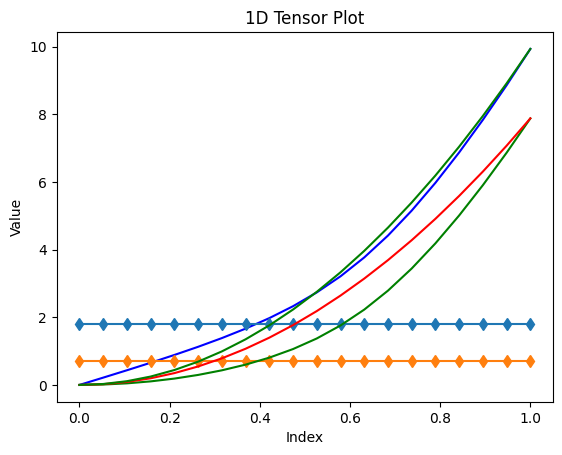

In [53]:
plot_vals = inverse_bessel_i0(vals).cpu().numpy()
lplot_vals = vals.log().cpu().numpy()
#plot_vals = vals.log().cpu().numpy()
ts = np.linspace(0, 1, 20)
plt.plot(ts, plot_vals, '-b')
plt.plot(ts, inverse_bessel_i0(torch.tensor([2])).cpu().numpy().repeat(20), '-d')
plt.plot(ts, torch.log(torch.tensor([2])).cpu().numpy().repeat(20), '-d')
plt.plot(ts, vals.log().cpu().numpy(), '-g')
plt.plot(ts, lplot_vals[-1] * ts**2, '-r')
plt.plot(ts, plot_vals[-1] * ts**2, '-g')
plt.title("1D Tensor Plot")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

In [151]:
plot_vals[-1]

np.float64(10.626847105227863)